In [5]:
import os
import cv2
import shutil
import random
import torch
from tqdm import tqdm
from ultralytics import YOLO

# 1. Limpieza estricta de la GPU (Previene crasheos de WSL)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f" GPU detectada y limpia: {torch.cuda.get_device_name(0)}")
else:
    print(" Trabajando en CPU. Revisa tu conexión de WSL con la GPU.")

 GPU detectada y limpia: NVIDIA GeForce RTX 3060 Laptop GPU


In [6]:
# 2. Configuración de Rutas (Montaje WSL)
BASE_PATH = '/mnt/c/Users/Turi/Downloads/13219972/CIDACC-dataset/dataset/distinct/'
IMG_SRC = os.path.join(BASE_PATH, 'images')
MSK_SRC = os.path.join(BASE_PATH, 'masks')
DEST_BASE = 'dataset_yolo'

# 3. Función Core: Transformar máscaras a polígonos
def mask_to_yolo(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: return []
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    yolo_polygons = []
    h, w = mask.shape
    for cnt in contours:
        if len(cnt) < 3: continue
        poly = cnt.reshape(-1, 2).astype(float)
        poly[:, 0] /= w; poly[:, 1] /= h
        poly_str = " ".join([f"{x:.6f} {y:.6f}" for x, y in poly])
        yolo_polygons.append(f"0 {poly_str}")
    return yolo_polygons

print(" Rutas y funciones preparadas.")

 Rutas y funciones preparadas.


In [7]:
# 4. Leer archivos
all_ids = [f.split('.')[0] for f in os.listdir(IMG_SRC) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# 5. Mezclar y Dividir (Semilla 42 para reproducibilidad)
random.seed(42)
random.shuffle(all_ids)
train_end = int(len(all_ids) * 0.6)
val_end = int(len(all_ids) * 0.9)
splits = {'train': all_ids[:train_end], 'val': all_ids[train_end:val_end], 'test': all_ids[val_end:]}

# 6. Reconstruir carpetas
if os.path.exists(DEST_BASE): shutil.rmtree(DEST_BASE)
for split, ids in splits.items():
    for sub in ["images", "labels"]: os.makedirs(os.path.join(DEST_BASE, split, sub), exist_ok=True)
    for name in tqdm(ids, desc=f"📦 Creando {split}"):
        img_f = next(f for f in os.listdir(IMG_SRC) if f.startswith(name))
        shutil.copy(os.path.join(IMG_SRC, img_f), os.path.join(DEST_BASE, split, "images", f"{name}.jpg"))
        
        mask_f = next(f for f in os.listdir(MSK_SRC) if f.startswith(name))
        with open(os.path.join(DEST_BASE, split, "labels", f"{name}.txt"), "w") as f:
            f.write("\n".join(mask_to_yolo(os.path.join(MSK_SRC, mask_f))))

# 7. Crear el archivo de configuración
with open('microalgas.yaml', "w") as f:
    f.write(f"path: {os.path.abspath(DEST_BASE)}\ntrain: train/images\nval: val/images\ntest: test/images\nnames:\n  0: Chlorella")

print(" Datos procesados exitosamente.")

📦 Creando test: 100%|██████████| 47/47 [00:01<00:00, 25.62it/s]

 Datos procesados exitosamente.


In [ ]:
ruta_mi_carpeta = '/mnt/c/Users/Turi/Desktop/ProyectoIA'
model = YOLO('yolov8n-seg.pt')
results = model.train(
    data='microalgas.yaml',
    epochs=100,
    imgsz=1080,
    batch=8,           
    workers=2,         
    device=0,      
    project = ruta_mi_carpeta,
    name='Modelo_Contador',
    exist_ok=True,
    amp=False,        
    plots=True,
    
   
    degrees=180.0,     # Rotación completa 
    fliplr=0.5,        # 50% probabilidad de espejo horizontal
    flipud=0.5,        # 50% probabilidad de espejo vertical
    hsv_h=0.015,       # Variación sutil de color
    hsv_s=0.7,         # Variación de saturación
    hsv_v=0.4          # Variación de luz/brillo del microscopio
)
print(" Entrenamiento finalizado con éxito.")

New https://pypi.org/project/ultralytics/8.4.56 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=microalgas.yaml, degrees=180.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scal

KeyboardInterrupt: 

In [ ]:
# 10. Cargar los mejores pesos obtenidos
best_model = YOLO('/mnt/c/Users/Turi/Desktop/ProyectoIA/Modelo_Contador/weights/best.pt')

# --- PARTE A: VALIDACIÓN EN SET DE TEST (10%) ---
print("\n EVALUANDO EL SET DE TEST (10%)")
# YOLO se encarga de aislar el set de 'test' definido en tu YAML
test_metrics = best_model.val(data='microalgas.yaml', split='test')

# --- PARTE B: EXTRACCIÓN DE MÉTRICAS ---
# YOLO entrega métricas tanto para la caja delimitadora (box) como para la máscara (seg).
# Para tu caso de contar y medir células, la máscara (seg) es la métrica más importante.

precision = test_metrics.seg.mp       # Mean Precision (Exactitud)
recall = test_metrics.seg.mr          # Mean Recall (Sensibilidad)
map50 = test_metrics.seg.map50        # Mean Average Precision a 50% de solapamiento (Métrica estándar)
map75 = test_metrics.seg.map75        # Mean Average Precision a 75% de solapamiento (Métrica estricta)

# Cálculo manual del F1-Score global
if (precision + recall) > 0:
    f1_score = 2 * (precision * recall) / (precision + recall)
else:
    f1_score = 0.0

print("\n --- REPORTE TÉCNICO DE SEGMENTACIÓN (MÁSCARAS) ---")
print(f" Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1_score:.4f}")
print(f" MAP 50%:    {map50:.4f} (Precisión general estándar)")
print(f" MAP 75%:    {map75:.4f} (Precisión general estricta - requiere polígonos muy exactos)")

# --- PARTE C: MATRIZ DE CONFUSIÓN Y GRÁFICOS AUTOMÁTICOS ---
print("\n📂 gráficos avanzados (Curvas F1, Precision-Recall) en la carpeta:")
print(f"👉 {test_metrics.save_dir}")


 EVALUANDO EL SET DE TEST (10%)
Ultralytics 8.4.47 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 1.8±0.1 ms, read: 15.8±2.9 MB/s, size: 47.0 KB)
val: Scanning /mnt/c/Users/Turi/AppData/Local/Programs/Microsoft VS Code/dataset_yolo/test/labels... 47 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 47/47 689.5it/s 0.1s
val: New cache created: /mnt/c/Users/Turi/AppData/Local/Programs/Microsoft VS Code/dataset_yolo/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6s/it 4.9s3.2ss
                   all         47        146      0.939      0.884      0.972        0.7      0.939      0.884      0.972       0.62
Speed: 17.0ms preprocess, 10.0ms inference, 0.0ms loss, 4.5ms postprocess per image
Results sav

📁 Probando con la imagen: /mnt/c/Users/Turi/AppData/Local/Programs/Microsoft VS Code/dataset_yolo/test/images/111.jpg
🔍 Evaluando con CONF: 0.6 | IOU: 0.8

image 1/1 /mnt/c/Users/Turi/AppData/Local/Programs/Microsoft VS Code/dataset_yolo/test/images/111.jpg: 640x640 2 Chlorellas, 9.3ms
Speed: 1.5ms preprocess, 9.3ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)


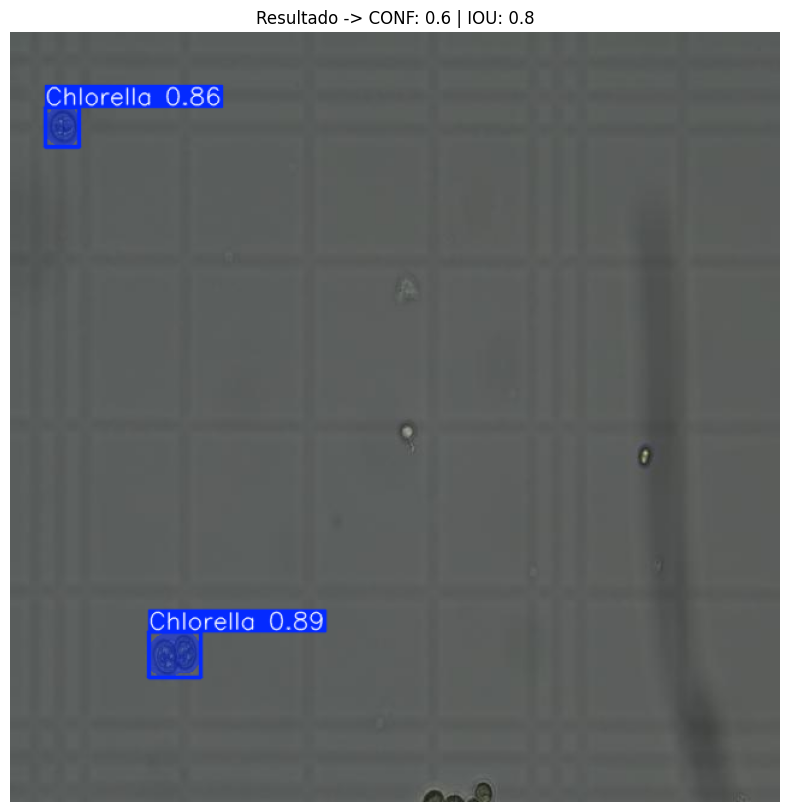

🦠 Total microalgas detectadas: 2



In [30]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Cargar tu modelo ya entrenado (asegúrate de que la ruta coincida con la tuya)
ruta_pesos = '/mnt/c/Users/Turi/Desktop/ProyectoIA/Modelo_Contador/weights/best.pt'

model = YOLO(ruta_pesos)

def probar_filtros_inferencia(imagen_prueba_path, umbral_confianza, umbral_iou):
    """
    imagen_prueba_path: Ruta a la imagen
    umbral_confianza: ID-4 (Reducción falsos positivos)
    umbral_iou: ID-5 (Ajuste para racimos densos)
    """
    print(f"🔍 Evaluando con CONF: {umbral_confianza} | IOU: {umbral_iou}")
    
    # Inferencia con inyección de parámetros
    resultados = model.predict(
        source=imagen_prueba_path,
        conf=umbral_confianza, 
        iou=umbral_iou,        
        retina_masks=True,     
        show=False
    )
    
    # Extraer y convertir imagen para visualización
    imagen_resultante = resultados[0].plot()
    imagen_rgb = cv2.cvtColor(imagen_resultante, cv2.COLOR_BGR2RGB)
    
    # Despliegue visual
    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_rgb)
    plt.axis('off')
    plt.title(f"Resultado -> CONF: {umbral_confianza} | IOU: {umbral_iou}")
    plt.show()
    
    # Retorno de conteo base
    conteo = len(resultados[0].boxes)
    print(f"🦠 Total microalgas detectadas: {conteo}\n")
    return resultados

# --- ZONA DE PRUEBAS ---
# Seleccionamos automáticamente la primera imagen de tu set de TEST
ruta_test_images = '/mnt/c/Users/Turi/AppData/Local/Programs/Microsoft VS Code/dataset_yolo/test/images'
primera_imagen_test = os.path.join(ruta_test_images, os.listdir(ruta_test_images)[1])

print(f"📁 Probando con la imagen: {primera_imagen_test}")

# Ejecución de la prueba:
# Ajusta el 0.60 (conf) para borrar basura y el 0.45 (iou) para separar racimos
resultados_prueba = probar_filtros_inferencia(
    imagen_prueba_path=primera_imagen_test, 
    umbral_confianza=0.60, 
    umbral_iou=0.8
)


image 1/1 /mnt/c/Users/Turi/AppData/Local/Programs/Microsoft VS Code/dataset_yolo/test/images/111.jpg: 1024x1024 10 Chlorellas, 117.3ms
Speed: 5.1ms preprocess, 117.3ms inference, 6.8ms postprocess per image at shape (1, 3, 1024, 1024)


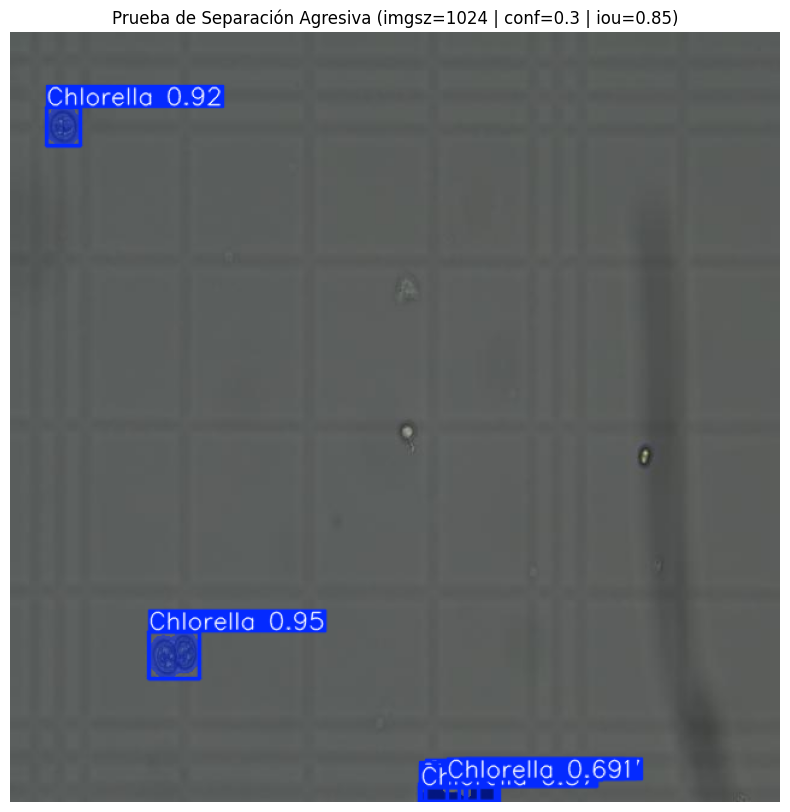

🦠 Total microalgas detectadas: 10


In [31]:
# Ejecución de la prueba con parámetros agresivos de separación
resultados_prueba = model.predict(
    source=primera_imagen_test, 
    conf=0.30,         # 1. BAJAMOS la confianza: Obligamos a la IA a mostrar predicciones más débiles que podría estar ocultando.
    iou=0.85,          # 2. MANTENEMOS el IoU altísimo: Prohibido fusionar.
    imgsz=1024,        # 3. NUEVO (Resolución): Le ponemos una "lupa". Al subir la resolución de 640 a 1024, la IA tiene más píxeles para notar la grieta oscura entre las dos células.
    retina_masks=True, # Mejora los bordes de la segmentación
    agnostic_nms=True, # Fuerza una separación más estricta ignorando las clases
    show=False
)

# Extraer y mostrar (Asegúrate de tener el %matplotlib inline arriba)
imagen_resultante = resultados_prueba[0].plot()
imagen_rgb = cv2.cvtColor(imagen_resultante, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(imagen_rgb)
plt.axis('off')
plt.title("Prueba de Separación Agresiva (imgsz=1024 | conf=0.3 | iou=0.85)")
plt.show()

conteo = len(resultados_prueba[0].boxes)
print(f"🦠 Total microalgas detectadas: {conteo}")